In [1]:
import pandas as pd

In [3]:
# Membaca dataset
df = pd.read_csv('/content/brazil_ecommerce_cleaned.csv')

In [4]:
# Memeriksa nilai duplikat
df.duplicated().sum()

np.int64(0)

In [7]:
# Memeriksa null values
df.isnull().sum()

,0
order_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,14
order_delivered_carrier_date,1154
order_delivered_customer_date,2378
order_estimated_delivery_date,0
customer_id,0
customer_unique_id,0
customer_city,0


In [9]:
df = df[df['order_status'] == 'delivered']

In [10]:
# Memeriksa null values
df.isnull().sum()

,0
order_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,14
order_delivered_carrier_date,1
order_delivered_customer_date,0
order_estimated_delivery_date,0
customer_id,0
customer_unique_id,0
customer_city,0


# Sales Trend

monthly revenue

In [17]:
# Ensure 'order_purchase_timestamp' is datetime
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

In [18]:
# Extract year and month
df['year_month'] = df['order_purchase_timestamp'].dt.to_period('M')

In [19]:
# Calculate monthly revenue
monthly_revenue = df.groupby('year_month')['price_x'].sum().reset_index()

In [20]:
# Convert 'year_month' back to datetime for plotting
monthly_revenue['year_month'] = monthly_revenue['year_month'].dt.to_timestamp()

In [21]:
monthly_revenue

,year_month,price_x
0,2016-09-01,134.970005
1,2016-10-01,40259.219852
2,2016-12-01,10.900000
3,2017-01-01,110194.719887
4,2017-02-01,225702.289840
5,2017-03-01,352741.679537
6,2017-04-01,331961.509561
7,2017-05-01,478210.919330
8,2017-06-01,416890.980087
9,2017-07-01,478636.660323


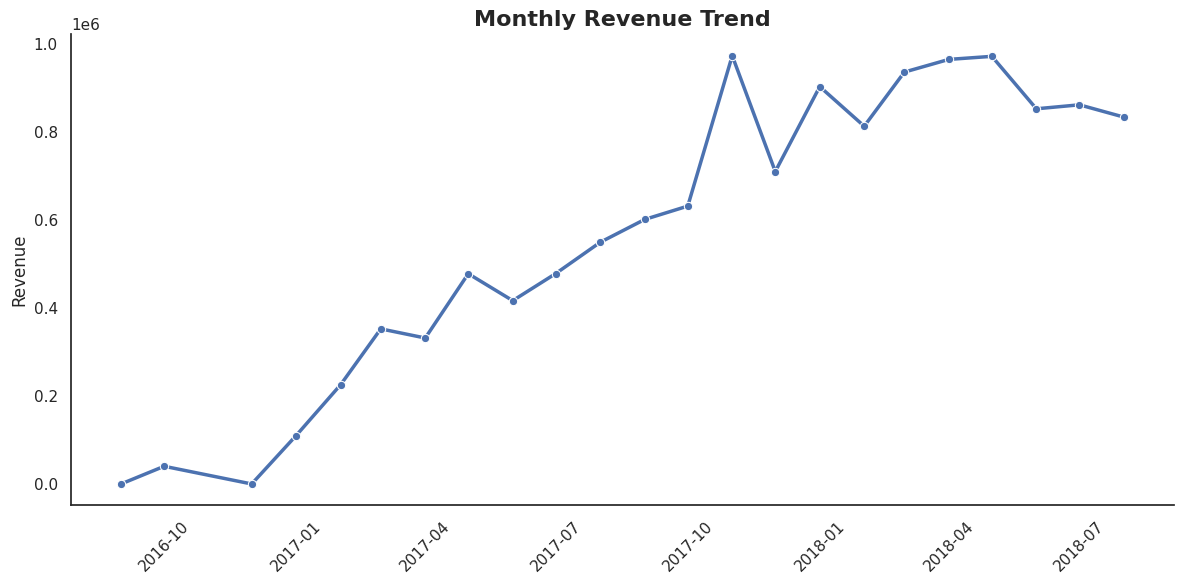

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

plt.figure(figsize=(12, 6))

sns.lineplot(
    x='year_month',
    y='price_x',
    data=monthly_revenue,
    marker='o',
    linewidth=2.5
)

plt.title('Monthly Revenue Trend', fontsize=16, weight='bold')
plt.xlabel('')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

sns.despine()

plt.tight_layout()
plt.show()

monthly revenue by product category

In [29]:
# Identify top 3 product categories by total revenue
top_3_categories = df.groupby('product_category_name_english')['price_x'].sum().nlargest(3).index

In [30]:
# Filter the DataFrame to include only these top 3 categories
df_top_categories = df[df['product_category_name_english'].isin(top_3_categories)]

In [31]:
# Calculate monthly revenue for each of the top 3 categories
monthly_revenue_top_categories = df_top_categories.groupby(['year_month', 'product_category_name_english'])['price_x'].sum().reset_index()

In [32]:
# Convert 'year_month' back to datetime for plotting
monthly_revenue_top_categories['year_month'] = monthly_revenue_top_categories['year_month'].dt.to_timestamp()

In [33]:
monthly_revenue_top_categories

,year_month,product_category_name_english,price_x
0,2016-09-01,health_beauty,134.970005
1,2016-10-01,bed_bath_table,478.989998
2,2016-10-01,health_beauty,3439.250015
3,2016-10-01,watches_gifts,2711.069983
4,2017-01-01,bed_bath_table,3804.360031
...,...,...,...
59,2018-07-01,health_beauty,103524.220212
60,2018-07-01,watches_gifts,94886.790066
61,2018-08-01,bed_bath_table,60891.089945
62,2018-08-01,health_beauty,119391.010418


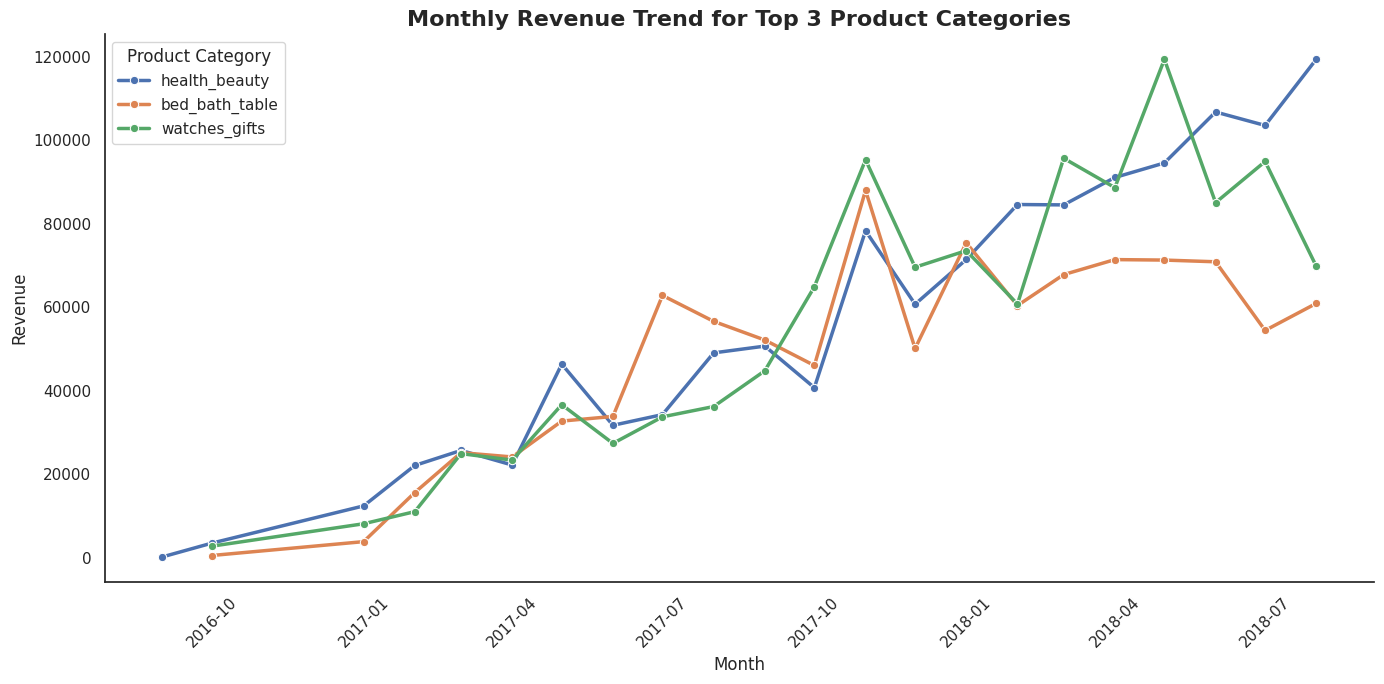

In [34]:
plt.figure(figsize=(14, 7))
sns.lineplot(
    x='year_month',
    y='price_x',
    hue='product_category_name_english',
    data=monthly_revenue_top_categories,
    marker='o',
    linewidth=2.5
)

plt.title('Monthly Revenue Trend for Top 3 Product Categories', fontsize=16, weight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.legend(title='Product Category')
sns.despine()
plt.tight_layout()
plt.show()

monthly revenue by customer state

In [35]:
# Identify top 3 customer states by total revenue
top_3_states = df.groupby('customer_state')['price_x'].sum().nlargest(3).index

In [36]:
# Filter the DataFrame to include only these top 3 states
df_top_states = df[df['customer_state'].isin(top_3_states)]

In [37]:
# Calculate monthly revenue for each of the top 3 states
monthly_revenue_top_states = df_top_states.groupby(['year_month', 'customer_state'])['price_x'].sum().reset_index()

In [38]:
# Convert 'year_month' back to datetime for plotting
monthly_revenue_top_states['year_month'] = monthly_revenue_top_states['year_month'].dt.to_timestamp()

In [39]:
monthly_revenue_top_states

,year_month,customer_state,price_x
0,2016-09-01,SP,134.970005
1,2016-10-01,MG,4274.949978
2,2016-10-01,RJ,8201.379990
3,2016-10-01,SP,11861.069902
4,2017-01-01,MG,15584.850005
...,...,...,...
59,2018-07-01,RJ,95985.290025
60,2018-07-01,SP,318843.129797
61,2018-08-01,MG,93637.929777
62,2018-08-01,RJ,93310.759973


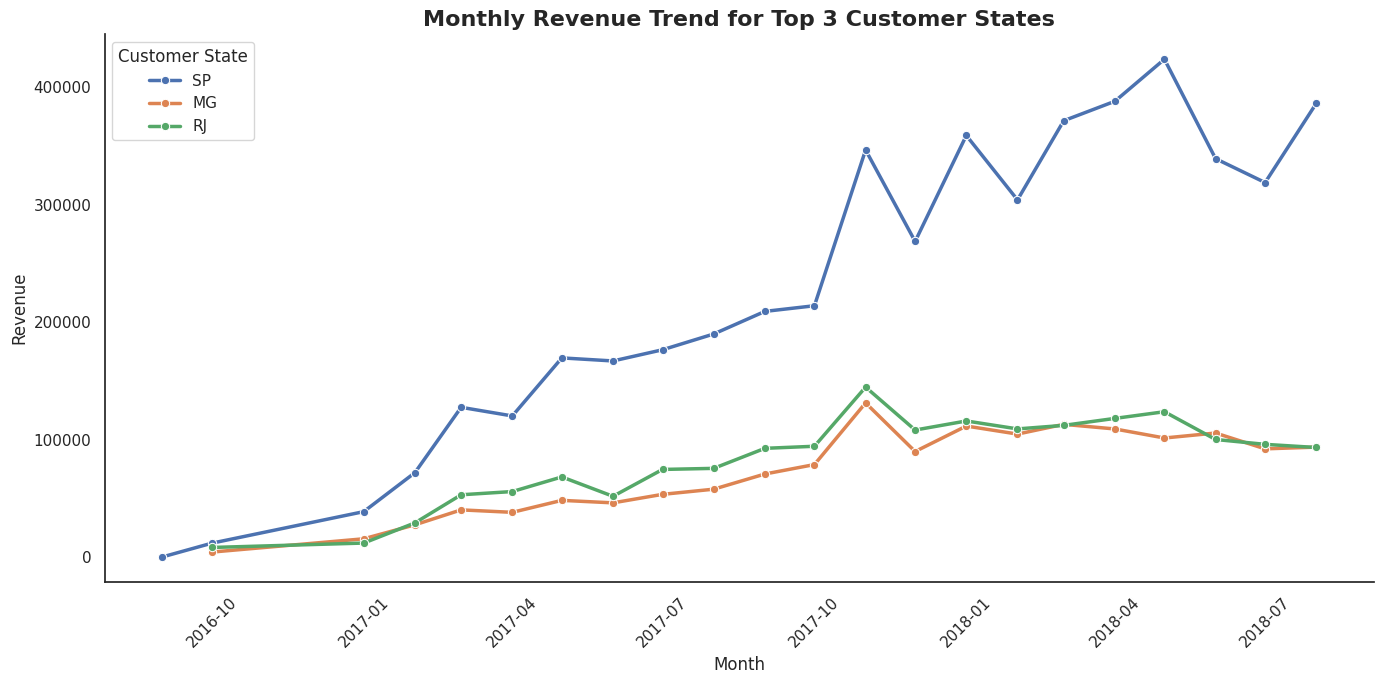

In [41]:
plt.figure(figsize=(14, 7))
sns.lineplot(
    x='year_month',
    y='price_x',
    hue='customer_state',
    data=monthly_revenue_top_states,
    marker='o',
    linewidth=2.5
)

plt.title('Monthly Revenue Trend for Top 3 Customer States', fontsize=16, weight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.legend(title='Customer State')
sns.despine()
plt.tight_layout()
plt.show()

monthly aov by product category

In [44]:
# Recalculate monthly data for top categories to include order count for AOV
monthly_data_top_categories = df_top_categories.groupby(['year_month', 'product_category_name_english']).agg(
    total_revenue=('price_x', 'sum'),
    order_count=('order_id', 'nunique') # Count unique orders per group
).reset_index()
display(monthly_data_top_categories.head())

,year_month,product_category_name_english,total_revenue,order_count
0,2016-09,health_beauty,134.970005,1
1,2016-10,bed_bath_table,478.989998,5
2,2016-10,health_beauty,3439.250015,36
3,2016-10,watches_gifts,2711.069983,4
4,2017-01,bed_bath_table,3804.360031,43


In [45]:
# Calculate Average Order Value (AOV)
monthly_data_top_categories['average_order_value'] = monthly_data_top_categories['total_revenue'] / monthly_data_top_categories['order_count']
display(monthly_data_top_categories.head())

,year_month,product_category_name_english,total_revenue,order_count,average_order_value
0,2016-09,health_beauty,134.970005,1,134.970005
1,2016-10,bed_bath_table,478.989998,5,95.798000
2,2016-10,health_beauty,3439.250015,36,95.534723
3,2016-10,watches_gifts,2711.069983,4,677.767496
4,2017-01,bed_bath_table,3804.360031,43,88.473489


In [46]:
# Convert 'year_month' back to datetime for plotting
monthly_data_top_categories['year_month'] = monthly_data_top_categories['year_month'].dt.to_timestamp()
display(monthly_data_top_categories.head())

,year_month,product_category_name_english,total_revenue,order_count,average_order_value
0,2016-09-01,health_beauty,134.970005,1,134.970005
1,2016-10-01,bed_bath_table,478.989998,5,95.798000
2,2016-10-01,health_beauty,3439.250015,36,95.534723
3,2016-10-01,watches_gifts,2711.069983,4,677.767496
4,2017-01-01,bed_bath_table,3804.360031,43,88.473489


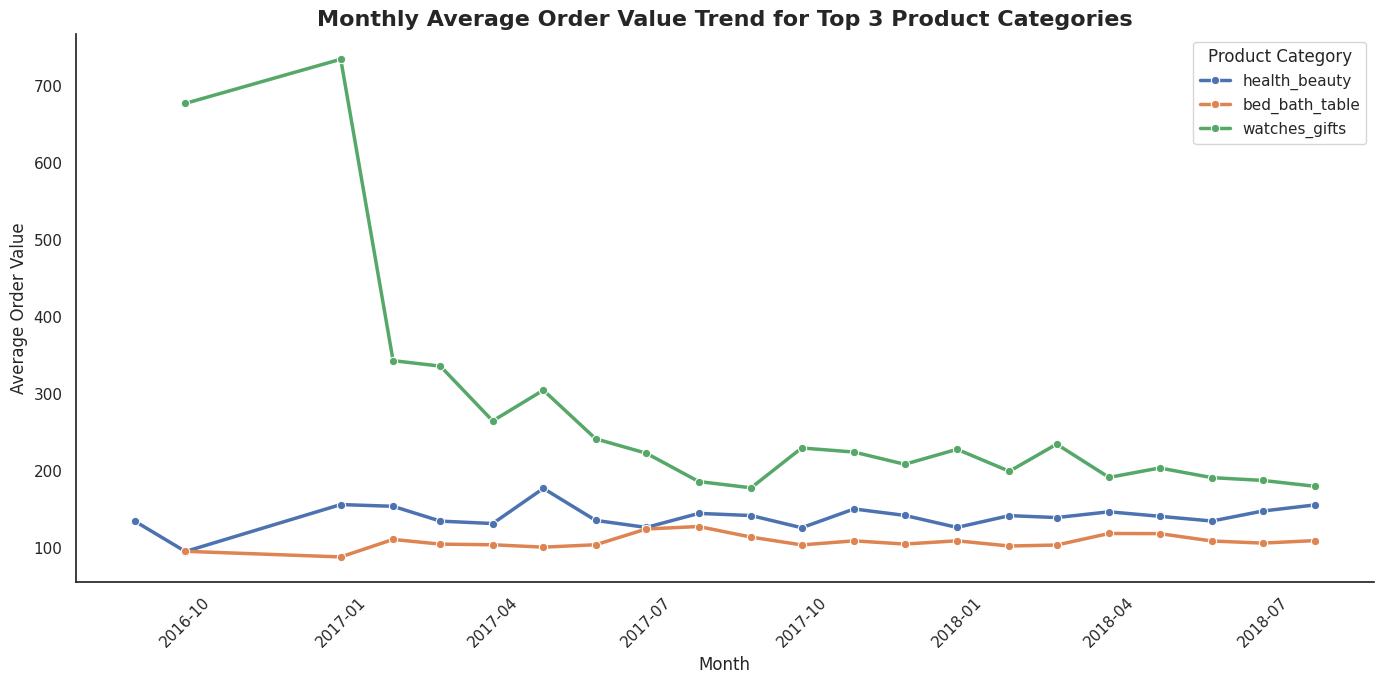

In [47]:
plt.figure(figsize=(14, 7))
sns.lineplot(
    x='year_month',
    y='average_order_value',
    hue='product_category_name_english',
    data=monthly_data_top_categories,
    marker='o',
    linewidth=2.5
)

plt.title('Monthly Average Order Value Trend for Top 3 Product Categories', fontsize=16, weight='bold')
plt.xlabel('Month')
plt.ylabel('Average Order Value')
plt.xticks(rotation=45)
plt.legend(title='Product Category')
sns.despine()
plt.tight_layout()
plt.show()

order count by product category

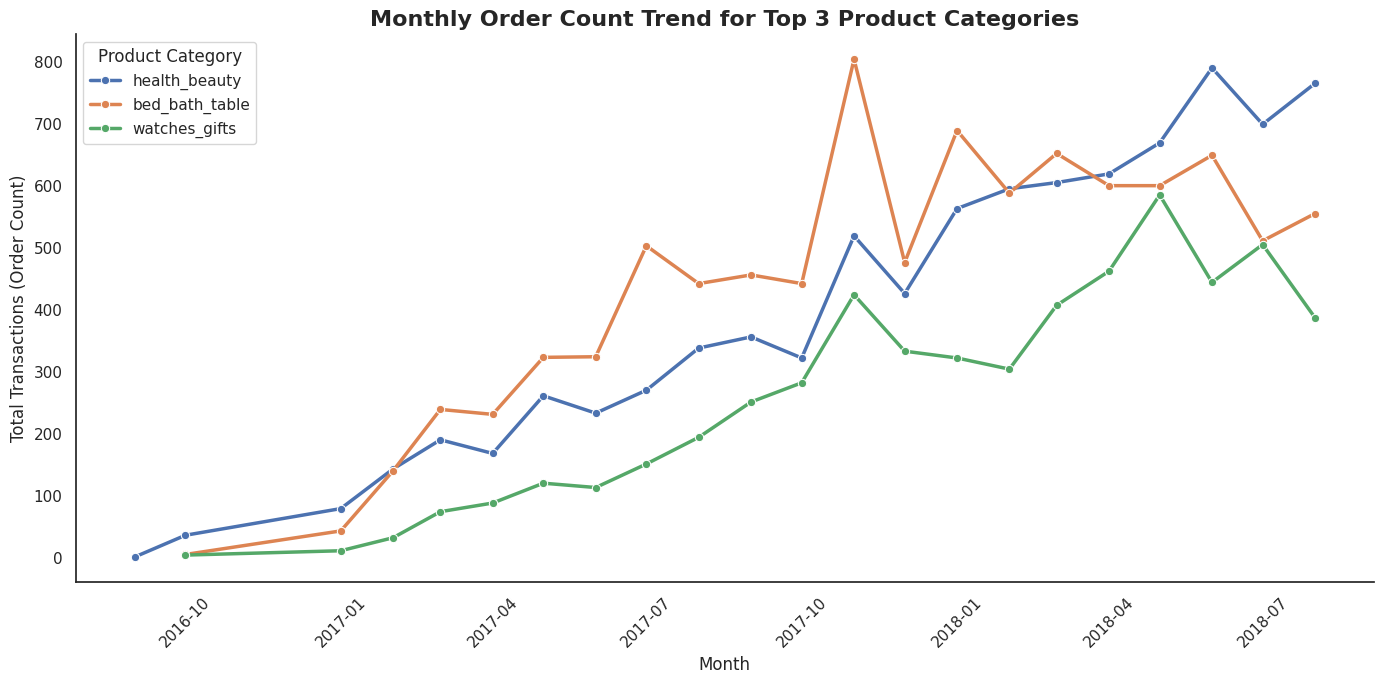

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.lineplot(
    x='year_month',
    y='order_count',
    hue='product_category_name_english',
    data=monthly_data_top_categories,
    marker='o',
    linewidth=2.5
)

plt.title('Monthly Order Count Trend for Top 3 Product Categories', fontsize=16, weight='bold')
plt.xlabel('Month')
plt.ylabel('Total Transactions (Order Count)')
plt.xticks(rotation=45)
plt.legend(title='Product Category')
sns.despine()
plt.tight_layout()
plt.show()

### Monthly Revenue Trend for Top 3 Product Categories per Top 3 States

In [49]:
# Filter the DataFrame to include only top 3 categories AND top 3 states
df_top_categories_states = df[
    df['product_category_name_english'].isin(top_3_categories) &
    df['customer_state'].isin(top_3_states)
]

In [56]:
# Calculate monthly revenue for each top 3 category within each top 3 state
monthly_revenue_top_categories_states = df_top_categories_states.groupby(['year_month', 'customer_state', 'product_category_name_english'])['price_x'].sum().reset_index()

# Convert 'year_month' back to datetime for plotting
monthly_revenue_top_categories_states['year_month'] = monthly_revenue_top_categories_states['year_month'].dt.to_timestamp()

In [57]:
monthly_revenue_top_categories_states

,year_month,customer_state,product_category_name_english,price_x
0,2016-09-01,SP,health_beauty,134.970005
1,2016-10-01,MG,bed_bath_table,169.899994
2,2016-10-01,MG,health_beauty,633.649992
3,2016-10-01,RJ,bed_bath_table,59.900002
4,2016-10-01,RJ,health_beauty,698.690010
...,...,...,...,...
184,2018-08-01,RJ,health_beauty,13098.250025
185,2018-08-01,RJ,watches_gifts,7864.940039
186,2018-08-01,SP,bed_bath_table,37305.789968
187,2018-08-01,SP,health_beauty,49676.600237


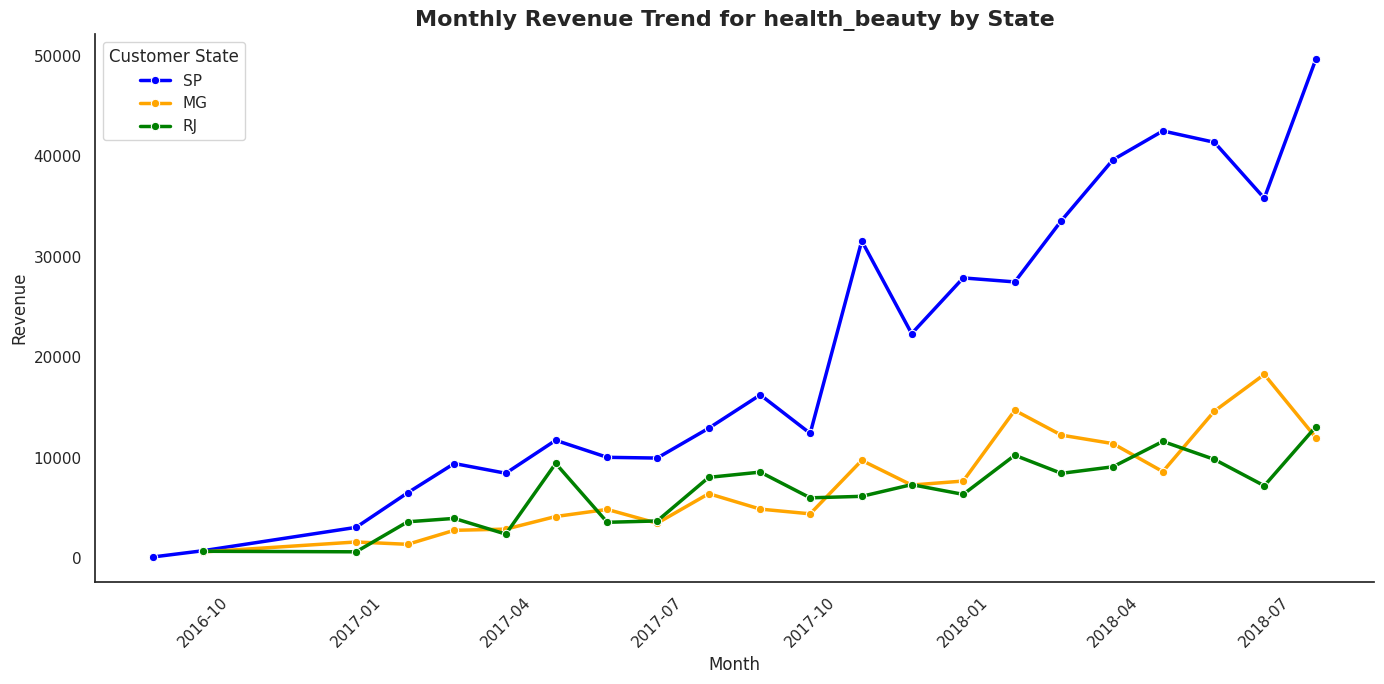

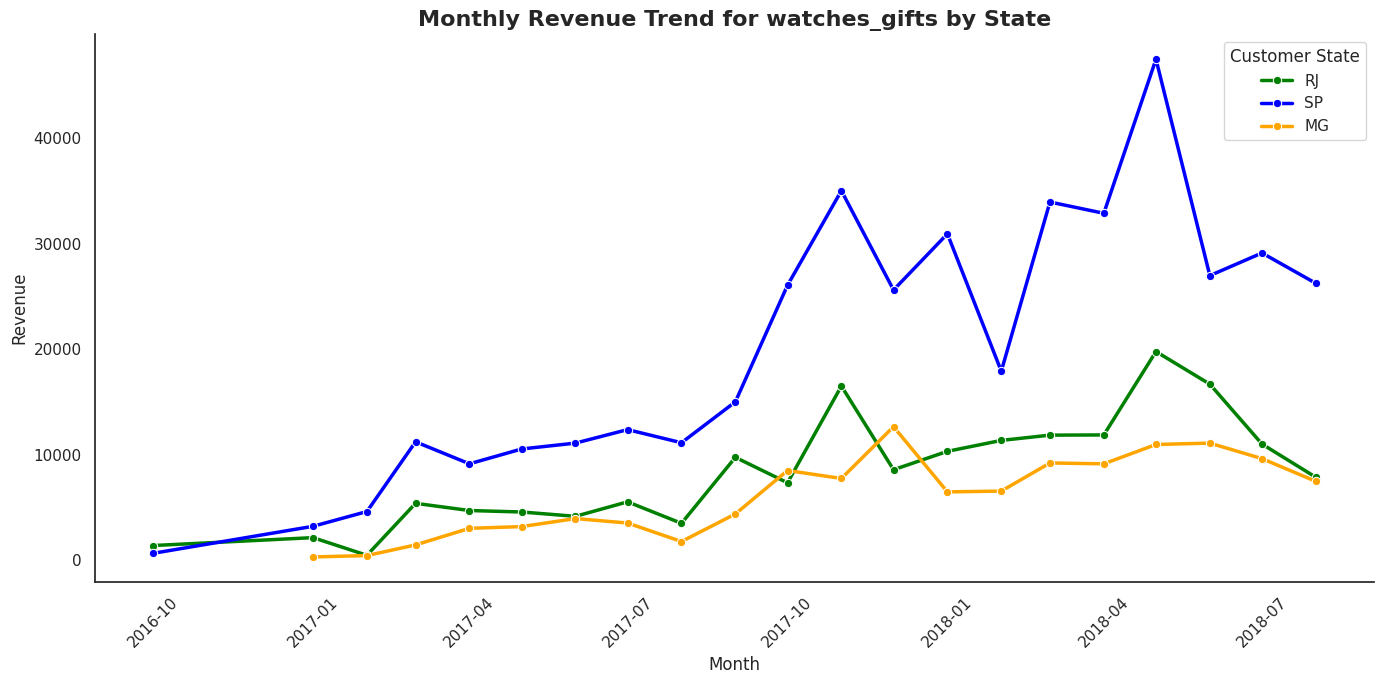

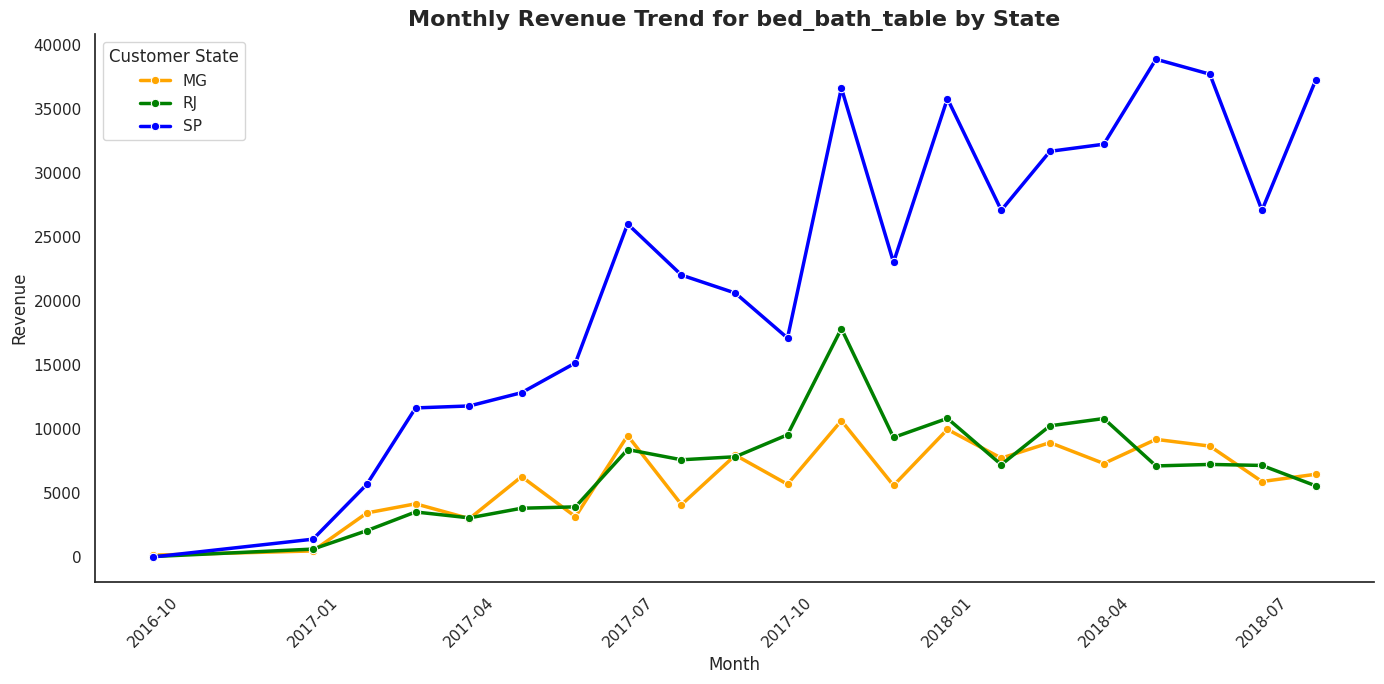

In [55]:
# Define a consistent color palette for the top 3 states as requested
state_colors = {
    'SP': 'blue',
    'MG': 'orange',
    'RJ': 'green'
}

import matplotlib.pyplot as plt
import seaborn as sns

# Generate a separate plot for each top product category, showing trends across top 3 states
for category in top_3_categories:
    plt.figure(figsize=(14, 7))
    df_plot_category = monthly_revenue_top_categories_states[
        monthly_revenue_top_categories_states['product_category_name_english'] == category
    ]

    sns.lineplot(
        x='year_month',
        y='price_x',
        hue='customer_state',
        data=df_plot_category,
        marker='o',
        linewidth=2.5,
        palette=state_colors # Use the predefined color palette
    )

    plt.title(f'Monthly Revenue Trend for {category} by State', fontsize=16, weight='bold')
    plt.xlabel('Month')
    plt.ylabel('Revenue')
    plt.xticks(rotation=45)
    plt.legend(title='Customer State')
    sns.despine()
    plt.tight_layout()
    plt.show()